# Tabular classification with Amazon SageMaker TabTransformer algorithm

---

This notebook's CI test result for us-west-2 is as follows. CI test results in other regions can be found at the end of the notebook. 

![This us-west-2 badge failed to load. Check your device's internet connectivity, otherwise the service is currently unavailable](https://prod.us-west-2.tcx-beacon.docs.aws.dev/sagemaker-nb/us-west-2/build_and_train_models|sm-tabtransformer_tabular_classification.ipynb)

---

---
This notebook demonstrates the use of Amazon SageMaker [TabTransformer](https://arxiv.org/abs/2012.06678) algorithm to train and host a tabular binary classification model. Tabular classification is the task of assigning a class to an example of structured or relational data. The Amazon SageMaker API for tabular classification can be used for classification of an example in two classes (binary classification) or more than two classes (multi-class classification).


In this notebook, we demonstrate two use cases of tabular classification models:

* How to train a tabular model on an example dataset to do binary classification.
* How to use the trained tabular model to perform inference, i.e., classifying new samples.

Note: This notebook was tested in Amazon SageMaker Studio on ml.t3.medium instance with Python 3 (Data Science) kernel.

---

1. [Set Up](#1.-Set-Up)
2. [Train A Tabular Model on Adult Dataset](#2.-Train-a-Tabular-Model-on-Adult-Dataset)
    * [Retrieve Training Artifacts](#2.1.-Retrieve-Training-Artifacts)
    * [Set Training Parameters](#2.2.-Set-Training-Parameters)
    * [Train with Automatic Model Tuning](#2.3.-Train-with-Automatic-Model-Tuning)   
    * [Start Training](#2.4.-Start-Training)
3. [Deploy and Run Inference on the Trained Tabular Model](#3.-Deploy-and-Run-Inference-on-the-Trained-Tabular-Model)
4. [Evaluate the Prediction Results Returned from the Endpoint](#4.-Evaluate-the-Prediction-Results-Returned-from-the-Endpoint)

## 1. Set Up

---
Before executing the notebook, there are some initial steps required for setup. This notebook requires latest version of sagemaker and ipywidgets.

---

In [1]:
# pip install disabled for papermill run (v3 installed in .v3test-venv)


---
To train and host on Amazon SageMaker, we need to setup and authenticate the use of AWS services. Here, we use the execution role associated with the current notebook instance as the AWS account role with SageMaker access. It has necessary permissions, including access to your data in S3.

---

In [2]:
import boto3, json
from sagemaker.core.helper.session_helper import Session, get_execution_role

boto3.setup_default_session(region_name="us-west-1")
sess = Session(boto_session=boto3.Session(region_name="us-west-1"))
try:
    aws_role = get_execution_role()
except Exception:
    aws_role = "arn:aws:iam::729646638167:role/service-role/AmazonSageMaker-ExecutionRole-20251201T194045"
aws_region = "us-west-1"
print("role:", aws_role, "region:", aws_region)

[07/15/26 16:31:28] INFO     Found credentials in shared credentials file: ~/.aws/credentials   ]8;id=15285315;file:///Users/lucasjia/pysdk/pysdk-workspace/.v3test-venv/lib/python3.12/site-packages/botocore/credentials.py\credentials.py]8;;\:]8;id=15285316;file:///Users/lucasjia/pysdk/pysdk-workspace/.v3test-venv/lib/python3.12/site-packages/botocore/credentials.py#1392\1392]8;;\

sagemaker.config INFO - Not applying SDK defaults from location: /Library/Application Support/sagemaker/config.yaml


sagemaker.config INFO - Not applying SDK defaults from location: /Users/lucasjia/Library/Application Support/sagemaker/config.yaml


                    INFO     Found credentials in shared credentials file: ~/.aws/credentials   ]8;id=15285321;file:///Users/lucasjia/pysdk/pysdk-workspace/.v3test-venv/lib/python3.12/site-packages/botocore/credentials.py\credentials.py]8;;\:]8;id=15285322;file:///Users/lucasjia/pysdk/pysdk-workspace/.v3test-venv/lib/python3.12/site-packages/botocore/credentials.py#1392\1392]8;;\

role: arn:aws:iam::729646638167:role/Admin region: us-west-1


## 2. Train a Tabular Model on Adult Dataset

---
In this demonstration, we will train a tabular algorithm on the [Adult](https://archive.ics.uci.edu/ml/datasets/adult) dataset. The dataset contains examples of census data to predict whether a person makes over 50K a year or not. The Adult dataset is downloaded from [UCI Machine Learning Repository](https://archive.ics.uci.edu/ml/datasets/adult).

Below is the table of the first 5 examples in the Adult dataset.

| Target | Feature_0 | Feature_1 | Feature_2 |  Feature_3   | Feature_4 | ...  | Feature_10 | Feature_11 | Feature_12 |    Feature_13    |
|:------:|:---------:|:---------:|:---------:|:------------:|:---------:|:----:|:----------:|:----------:|:----------:|:----------------:|
|   0    |    25     |  Private  |  226802   |     11th     |     7     | ...  |     0      |     0      |     40     |  United-States   |
|   0    |    38     |  Private  |   89814   |   HS-grad    |     9     | ...  |     0      |     0      |     50     |  United-States   |
|   1    |    28     | Local-gov |  336951   |  Assoc-acdm  |    12     | ...  |     0      |     0      |     40     |  United-States   |
|   1    |    44     |  Private  |  160323   | Some-college |    10     | ...  |    7688    |     0      |     40     |  United-States   |
|   0    |    18     |     ?     |  103497   | Some-college |    10     | ...  |     0      |     0      |     30     |  United-States   |


If you want to bring your own dataset, below are the instructions on how the training data should be formatted as input to the model.

A S3 path should contain two sub-directories 'train/', 'validation/' (optional), and a json-format file named 'categorical_index.json' (optional). Each sub-directory contains a 'data.csv' file (The ABALONE dataset used in this example has been prepared and saved in `training_dataset_s3_path` shown below).

* The 'data.csv' files under sub-directory 'train/' and 'validation/' are for training and validation, respectively. The validation data is used to compute a validation score at the end of each boosting iteration. An early stopping is applied when the validation score stops improving. If the validation data is not provided, a 20% of training data is randomly sampled to serve as the validation data.

* The first column of the 'data.csv' should have the corresponding target variable. The rest of other columns should have the corresponding predictor variables (features).

* If the predictors include categorical feature(s), a json-format file named 'categorical_index.json' should be included in the input directory to indicate the column index(es) of the categorical features. Within the json-format file, it should have a python directory where the key is a string of 'cat_index_list' and the value is a list of unique integer(s). Each integer in the list indicates the column index of categorical features in the 'data.csv'. The range of each integer should be more than 0 (index 0 indicates the target) and less than the total number of columns. If the data set does not contain any categorical feature, the TabTransformer algorithm is equivalently a multi-layer perceptron (MLP).

* The target column must be encoded as non-negative integers (```int```) less than ```Int32.MaxValue``` (2147483647). It is best to use a contiguous range of integers started from zero.

* All the categorical features do not need to be encoded as non-negative integers and can be kept as their original formats.

* Note. The number of json-format files should be no more than 1 in the input directory.

Citations:

- Dua, D. and Graff, C. (2019). UCI Machine Learning Repository [http://archive.ics.uci.edu/ml]. Irvine, CA: University of California, School of Information and Computer Science.

### 2.1. Retrieve Training Artifacts

___

Here, we retrieve the training docker container, the training algorithm source, and the tabular algorithm. Note that model_version="*" fetches the latest model.

For the training algorithm, we have one choice in this demonstration.
* [TabTransformer](https://arxiv.org/abs/2012.06678): To use this algorithm, specify `train_model_id` as `pytorch-tabtransformerclassification-model` in the cell below.

Note. [LightGBM](https://lightgbm.readthedocs.io/en/latest/) (`train_model_id: lightgbm-classification-model`), [CatBoost](https://catboost.ai/en/docs/) (`train_model_id:catboost-classification-model`), [XGBoost](https://xgboost.readthedocs.io/en/latest/) (`train_model_id: xgboost-classification-model`), [Linear Learner](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html#sklearn.linear_model.LogisticRegression) (`train_model_id: sklearn-classification-linear`), and [AutoGluon Tabular](https://auto.gluon.ai/stable/tutorials/tabular_prediction/index.html) (`train_model_id: autogluon-classification-ensemble`) are the other choices in the tabular classification category. Since they have different input-format requirements, please check separate notebooks `lightgbm_catboost_tabular/Amazon_Tabular_Classification_LightGBM_CatBoost.ipynb`, `xgboost_linear_learner_tabular/Amazon_Tabular_Classification_XGBoost_LinearLearner.ipynb`, and `autogluon_tabular/Amazon_Tabular_Classification_AutoGluon.ipynb` for details.


---

In [3]:
# Choose the JumpStart TabTransformer tabular classification model. The v3
# ModelTrainer.from_jumpstart_config(...) call below resolves the training image,
# source code, pre-trained model artifact and default hyperparameters automatically
# from this model_id, so the separate image_uris/model_uris/script_uris.retrieve
# calls used in v2 are no longer needed for training.
train_model_id, train_model_version, train_scope = (
    "pytorch-tabtransformerclassification-model",
    "*",
    "training",
)
training_instance_type = "ml.m5.2xlarge"

### 2.2. Set Training Parameters

---

Now that we are done with all the setup that is needed, we are ready to train our tabular algorithm. To begin, let us create a [``sageMaker.estimator.Estimator``](https://sagemaker.readthedocs.io/en/stable/api/training/estimators.html) object. This estimator will launch the training job. 

There are two kinds of parameters that need to be set for training. The first one are the parameters for the training job. These include: (i) Training data path. This is S3 folder in which the input data is stored, (ii) Output path: This the s3 folder in which the training output is stored. (iii) Training instance type: This indicates the type of machine on which to run the training.

The second set of parameters are algorithm specific training hyper-parameters. 

---

In [4]:
# Sample training data is available in this bucket
training_data_bucket = f"jumpstart-cache-prod-{aws_region}"
training_data_prefix = "training-datasets/tabular_binary/"

training_dataset_s3_path = f"s3://{training_data_bucket}/{training_data_prefix}"

output_bucket = sess.default_bucket()
output_prefix = "jumpstart-example-tabular-training"
default_bucket_prefix = sess.default_bucket_prefix

# If a default bucket prefix is specified, append it to the s3 path
if default_bucket_prefix:
    output_prefix = f"{default_bucket_prefix}/{output_prefix}"

s3_output_location = f"s3://{output_bucket}/{output_prefix}/output"

---
For algorithm specific hyper-parameters, we start by fetching python dictionary of the training hyper-parameters that the algorithm accepts with their default values. This can then be overridden to custom values.

---

In [5]:
from sagemaker.core import hyperparameters

# Retrieve the default hyper-parameters for fine-tuning the model
hyperparameters = hyperparameters.retrieve_default(
    model_id=train_model_id, model_version=train_model_version
)

# [Optional] Override default hyperparameters with custom values
hyperparameters["n_epochs"] = "80"
print(hyperparameters)

[07/15/26 16:31:29] INFO     Found credentials in shared credentials file: ~/.aws/credentials   ]8;id=15285327;file:///Users/lucasjia/pysdk/pysdk-workspace/.v3test-venv/lib/python3.12/site-packages/botocore/credentials.py\credentials.py]8;;\:]8;id=15285328;file:///Users/lucasjia/pysdk/pysdk-workspace/.v3test-venv/lib/python3.12/site-packages/botocore/credentials.py#1392\1392]8;;\

Using model 'pytorch-tabtransformerclassification-model' with wildcard version identifier '*'. You can pin to version '2.0.26' for more stable results. Note that models may have different input/output signatures after a major version upgrade.


                    WARNING  Using model 'pytorch-tabtransformerclassification-model' with wildcard    ]8;id=15285335;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/jumpstart/cache.py\cache.py]8;;\:]8;id=15285336;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/jumpstart/cache.py#624\624]8;;\
                             version identifier '*'. You can pin to version '2.0.26' for more stable               
                             results. Note that models may have different input/output signatures                  
                             after a major version upgrade.                                                        

{'n_epochs': '80', 'patience': '10', 'learning_rate': '0.001', 'batch_size': '256', 'input_dim': '32', 'n_blocks': '4', 'attn_dropout': '0.2', 'mlp_dropout': '0.1', 'frac_shared_embed': '0.25'}


### 2.3. Train with Automatic Model Tuning  


Amazon SageMaker automatic model tuning, also known as hyperparameter tuning, finds the best version of a model by running many training jobs on your dataset using the algorithm and ranges of hyperparameters that you specify. It then chooses the hyperparameter values that result in a model that performs the best, as measured by a metric that you choose. We will use a HyperparameterTuner object to interact with Amazon SageMaker hyperparameter tuning APIs.

In [6]:
from sagemaker.core.parameter import (
    ContinuousParameter,
    CategoricalParameter,
)

use_amt = True

hyperparameter_ranges = {
    "learning_rate": ContinuousParameter(0.001, 0.01, scaling_type="Auto"),
    "batch_size": CategoricalParameter([128, 256, 512]),
    "attn_dropout": ContinuousParameter(0.0, 0.8, scaling_type="Auto"),
    "mlp_dropout": ContinuousParameter(0.0, 0.8, scaling_type="Auto"),
}

### 2.4. Start Training

---
We start by creating the estimator object with all the required assets and then launch the training job.

---

In [7]:
from sagemaker.train import ModelTrainer
from sagemaker.train.configs import Compute, InputData
from sagemaker.train.tuner import HyperparameterTuner
from sagemaker.core.jumpstart import JumpStartConfig
from sagemaker.core.shapes import OutputDataConfig
from sagemaker.core.common_utils import name_from_base

training_job_name = name_from_base(f"jumpstart-{train_model_id}-training")

# Build the ModelTrainer from the JumpStart config. The training image, source
# code, pre-trained model artifact and environment are resolved automatically from
# the model ID. JumpStartConfig resolves the latest hub content version when
# model_version is left unset.
jumpstart_config = JumpStartConfig(model_id=train_model_id)

tabular_trainer = ModelTrainer.from_jumpstart_config(
    jumpstart_config=jumpstart_config,
    role=aws_role,
    sagemaker_session=sess,
    compute=Compute(
        instance_type=training_instance_type,
        instance_count=1,
    ),
    hyperparameters=hyperparameters,
    output_data_config=OutputDataConfig(s3_output_path=s3_output_location),
    base_job_name=training_job_name,
)

if use_amt:
    # The JumpStart ModelTrainer auto-attaches JumpStart identification tags as Tag
    # objects. The HyperparameterTuner serializes tags assuming the dict form
    # (tag["Key"]), so we clear these Tag objects before tuning to avoid a
    # 'Tag' object is not subscriptable error. The tuning job still gets the
    # JumpStart URI tags that the tuner adds internally in dict form.
    tabular_trainer.tags = []

    tuner = HyperparameterTuner(
        model_trainer=tabular_trainer,
        objective_metric_name="f1_score",
        hyperparameter_ranges=hyperparameter_ranges,
        metric_definitions=[{"Name": "f1_score", "Regex": "metrics={'f1': (\\S+)}"}],
        max_jobs=2,  # execution-copy: reduced from 10 to limit cost
        max_parallel_jobs=2,
        objective_type="Maximize",
        base_tuning_job_name=training_job_name,
    )

    tuner.tune(
        inputs=[
            InputData(channel_name="training", data_source=training_dataset_s3_path)
        ],
    )
else:
    # Launch a single SageMaker Training job by passing the s3 path of the training data
    tabular_trainer.train(
        input_data_config=[
            InputData(channel_name="training", data_source=training_dataset_s3_path)
        ],
    )

[07/15/26 16:31:30] INFO     Role 'arn:aws:iam::729646638167:role/Admin' validated for     ]8;id=15285343;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/helper/iam_role_resolver.py\iam_role_resolver.py]8;;\:]8;id=15285344;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/helper/iam_role_resolver.py#598\598]8;;\
                             training. Using it.                                                                   

                    INFO     Runs on sagemaker prod, region:us-west-1                                  ]8;id=15285351;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/utils/utils.py\utils.py]8;;\:]8;id=15285352;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/utils/utils.py#375\375]8;;\

                    INFO     Found credentials in shared credentials file: ~/.aws/credentials   ]8;id=15285357;file:///Users/lucasjia/pysdk/pysdk-workspace/.v3test-venv/lib/python3.12/site-packages/botocore/credentials.py\credentials.py]8;;\:]8;id=15285358;file:///Users/lucasjia/pysdk/pysdk-workspace/.v3test-venv/lib/python3.12/site-packages/botocore/credentials.py#1392\1392]8;;\

                    INFO     hub_content_name: pytorch-tabtransformerclassification-model,           ]8;id=15285365;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/jumpstart/document.py\document.py]8;;\:]8;id=15285366;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/jumpstart/document.py#71\71]8;;\
                             hub_content_version: 2.0.26                                                           

                    INFO     Networking not provided. Using default networking:                     ]8;id=15285373;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-train/src/sagemaker/train/defaults.py\defaults.py]8;;\:]8;id=15285374;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-train/src/sagemaker/train/defaults.py#314\314]8;;\
                             security_group_ids=None subnets=None enable_network_isolation=True                    
                             enable_inter_container_traffic_encryption=None                                        

...

                    INFO     StoppingCondition not provided. Using default:                         ]8;id=15285421;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-train/src/sagemaker/train/defaults.py\defaults.py]8;;\:]8;id=15285422;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-train/src/sagemaker/train/defaults.py#167\167]8;;\
                             max_runtime_in_seconds=3600 max_wait_time_in_seconds=None                             
                             max_pending_time_in_seconds=None                                                      

                    INFO     Training image URI:                                               ]8;id=15285429;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-train/src/sagemaker/train/model_trainer.py\model_trainer.py]8;;\:]8;id=15285430;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-train/src/sagemaker/train/model_trainer.py#558\558]8;;\
                             763104351884.dkr.ecr.us-west-1.amazonaws.com/pytorch-training:1.9                     
                             .0-cpu-py38                                                                           

[07/15/26 16:31:32] INFO     Creating hyper_parameter_tuning_job resource.                       ]8;id=15285437;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py\resources.py]8;;\:]8;id=15285438;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py#14973\14973]8;;\

Output()

[07/15/26 16:39:32] INFO     Final Resource Status: Completed                                    ]8;id=15285444;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py\resources.py]8;;\:]8;id=15285445;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py#15202\15202]8;;\

## 3. Deploy and Run Inference on the Trained Tabular Model

---

In this section, you learn how to query an existing endpoint and make predictions of the examples you input. For each example, the model will output the probability of the sample for each class in the model. 
Next, the predicted class label is obtained by taking the class label with the maximum probability over others. Throughout the notebook, the examples are taken from the [Adult](https://archive.ics.uci.edu/ml/datasets/adult) test set.
The dataset contains examples of census data to predict whether a person makes over 50K a year or not.


We start by retrieving the jumpstart artifacts and deploy the `tabular_estimator` that we trained.

---

In [8]:
from sagemaker.core import image_uris, script_uris
from sagemaker.core.resources import TrainingJob, Model, EndpointConfig, Endpoint
from sagemaker.core.shapes import ContainerDefinition, ProductionVariant
from sagemaker.core.common_utils import name_from_base

inference_instance_type = "ml.m5.2xlarge"

# Retrieve the inference docker container uri
deploy_image_uri = image_uris.retrieve(
    region=aws_region,
    framework=None,
    image_scope="inference",
    model_id=train_model_id,
    model_version=train_model_version,
    instance_type=inference_instance_type,
)
# Retrieve the inference script uri (source directory tarball). The JumpStart
# inference container downloads and runs inference.py from this
# SAGEMAKER_SUBMIT_DIRECTORY.
deploy_source_uri = script_uris.retrieve(
    model_id=train_model_id, model_version=train_model_version, script_scope="inference"
)

# Identify the best model artifact produced by tuning (or the single training job).
if use_amt:
    best_training_job_name = tuner.best_training_job()
else:
    best_training_job_name = tabular_trainer._latest_training_job.training_job_name
print(f"Best training job: {best_training_job_name}")

model_data = TrainingJob.get(best_training_job_name).model_artifacts.s3_model_artifacts

model_name = name_from_base(f"jumpstart-example-{train_model_id}-model")
endpoint_config_name = name_from_base(f"jumpstart-example-{train_model_id}-config")
endpoint_name = name_from_base(f"jumpstart-example-{train_model_id}-")

# The trained artifact does not bundle the inference script, so we point the
# container at the JumpStart inference source directory via SAGEMAKER_SUBMIT_DIRECTORY.
tabular_model = Model.create(
    model_name=model_name,
    primary_container=ContainerDefinition(
        image=deploy_image_uri,
        model_data_url=model_data,
        environment={
            "SAGEMAKER_PROGRAM": "inference.py",
            "SAGEMAKER_SUBMIT_DIRECTORY": deploy_source_uri,
            "MODEL_CACHE_ROOT": "/opt/ml/model",
            "SAGEMAKER_ENV": "1",
            "SAGEMAKER_MODEL_SERVER_WORKERS": "1",
        },
    ),
    execution_role_arn=aws_role,
)

endpoint_config = EndpointConfig.create(
    endpoint_config_name=endpoint_config_name,
    production_variants=[
        ProductionVariant(
            variant_name="AllTraffic",
            model_name=model_name,
            instance_type=inference_instance_type,
            initial_instance_count=1,
            initial_variant_weight=1,
        )
    ],
)

predictor = Endpoint.create(
    endpoint_name=endpoint_name,
    endpoint_config_name=endpoint_config_name,
)
predictor.wait_for_status("InService")

Best training job: jumpstart-pytorch-ta-260715-1631-002-6a91c74d
sagemaker.config INFO - Not applying SDK defaults from location: /Library/Application Support/sagemaker/config.yaml


sagemaker.config INFO - Not applying SDK defaults from location: /Users/lucasjia/Library/Application Support/sagemaker/config.yaml


                    INFO     Creating model resource.                                            ]8;id=15296661;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py\resources.py]8;;\:]8;id=15296662;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py#20593\20593]8;;\

[07/15/26 16:39:35] INFO     Creating endpoint_config resource.                                  ]8;id=15296668;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py\resources.py]8;;\:]8;id=15296669;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py#11069\11069]8;;\

                    INFO     Creating endpoint resource.                                         ]8;id=15296675;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py\resources.py]8;;\:]8;id=15296676;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py#10228\10228]8;;\

Output()

[07/15/26 16:43:14] INFO     Final Resource Status: InService                                    ]8;id=15296682;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py\resources.py]8;;\:]8;id=15296683;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py#10484\10484]8;;\

---
Next, we download a hold-out Adult test data from the S3 bucket for inference.

---

In [9]:
jumpstart_assets_bucket = f"jumpstart-cache-prod-{aws_region}"
test_data_prefix = "training-datasets/tabular_binary/test"
test_data_file_name = "data.csv"

boto3.client("s3").download_file(
    jumpstart_assets_bucket, f"{test_data_prefix}/{test_data_file_name}", test_data_file_name
)

---
Next, we read the Adult test data into pandas data frame, prepare the ground truth target and predicting features to send into the endpoint.

Below is the screenshot of the first 5 examples in the Adult test set. All of the test examples with features
from ```Feature_0``` to ```Feature_13``` are sent into the deployed model to get model predictions,
to estimate the ground truth ```target``` column. For each test example, the model will output
a vector of ```num_classes``` elements, where each element is the probability of the example for each class in the model.
The ```num_classes``` is 2 in this case. Next, the predicted class label is obtained by taking the class label
with the maximum probability over others. 

---

In [10]:
newline, bold, unbold = "\n", "\033[1m", "\033[0m"

import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

# read the data
test_data = pd.read_csv(test_data_file_name, header=None)
test_data.columns = ["Target"] + [f"Feature_{i}" for i in range(1, test_data.shape[1])]

num_examples, num_columns = test_data.shape
print(
    f"{bold}The test dataset contains {num_examples} examples and {num_columns} columns.{unbold}\n"
)

# prepare the ground truth target and predicting features to send into the endpoint.
ground_truth_label, features = test_data.iloc[:, :1], test_data.iloc[:, 1:]

print(f"{bold}The first 5 observations of the data: {unbold} \n")
test_data.head(5)

The test dataset contains 16281 examples and 15 columns.

The first 5 observations of the data:  



,Target,Feature_1,Feature_2,Feature_3,Feature_4,Feature_5,Feature_6,Feature_7,Feature_8,Feature_9,Feature_10,Feature_11,Feature_12,Feature_13,Feature_14
0,0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States
1,0,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States
2,1,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States
3,1,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States
4,0,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States


---
The following code queries the endpoint you have created to get the prediction for each test example. 
The `query_endpoint()` function returns an array-like of shape (num_examples, num_classes), where each row indicates
the probability of the example for each class in the model. The num_classes is 2 in above test data.
Next, the predicted class label is obtained by taking the class label with the maximum probability over others for each example. 

---

In [11]:
content_type = "text/csv"


def query_endpoint(encoded_tabular_data):
    response = predictor.invoke(
        body=encoded_tabular_data, content_type=content_type
    )
    return response


def parse_response(query_response):
    model_predictions = json.loads(query_response.body.read())
    predicted_probabilities = model_predictions["probabilities"]
    return np.array(predicted_probabilities)


# split the test data into smaller size of batches to query the endpoint due to the large size of test data.
batch_size = 1500
predict_prob = []
for i in np.arange(0, num_examples, step=batch_size):
    query_response_batch = query_endpoint(
        features.iloc[i : (i + batch_size), :].to_csv(header=False, index=False).encode("utf-8")
    )
    predict_prob_batch = parse_response(query_response_batch)  # prediction probability per batch
    predict_prob.append(predict_prob_batch)


predict_prob = np.concatenate(predict_prob, axis=0)
predict_label = np.argmax(predict_prob, axis=1)

## 4. Evaluate the Prediction Results Returned from the Endpoint

---
We evaluate the predictions results returned from the endpoint by following two ways.

* Visualize the predictions results by plotting the confusion matrix.

* Measure the prediction results quantitatively.

---

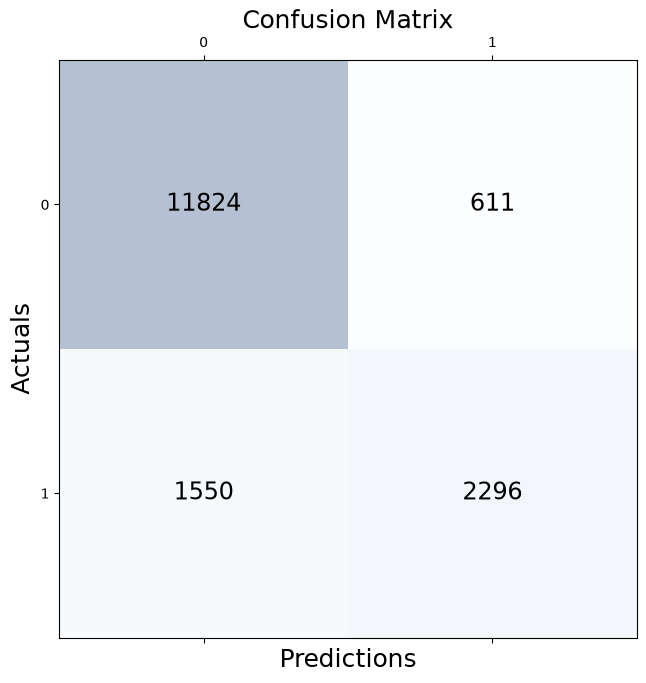

In [12]:
# Visualize the predictions results by plotting the confusion matrix.
conf_matrix = confusion_matrix(y_true=ground_truth_label.values, y_pred=predict_label)
fig, ax = plt.subplots(figsize=(7.5, 7.5))
ax.matshow(conf_matrix, cmap=plt.cm.Blues, alpha=0.3)
for i in range(conf_matrix.shape[0]):
    for j in range(conf_matrix.shape[1]):
        ax.text(x=j, y=i, s=conf_matrix[i, j], va="center", ha="center", size="xx-large")

plt.xlabel("Predictions", fontsize=18)
plt.ylabel("Actuals", fontsize=18)
plt.title("Confusion Matrix", fontsize=18)
plt.show()

In [13]:
# Measure the prediction results quantitatively.
eval_accuracy = accuracy_score(ground_truth_label.values, predict_label)
eval_f1 = f1_score(ground_truth_label.values, predict_label)

print(
    f"{bold}Evaluation result on test data{unbold}:{newline}"
    f"{bold}{accuracy_score.__name__}{unbold}: {eval_accuracy}{newline}"
    f"{bold}F1 {unbold}: {eval_f1}{newline}"
)

Evaluation result on test data:
accuracy_score: 0.8672685952951293
F1 : 0.6799940767066489



---
Next, we delete the endpoint corresponding to the trained model.

---

In [14]:
# Delete the SageMaker endpoint and the attached resources
predictor.delete()
endpoint_config.delete()
tabular_model.delete()

[07/15/26 16:43:24] INFO     Deleting Endpoint -                                                 ]8;id=15301783;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py\resources.py]8;;\:]8;id=15301784;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py#10428\10428]8;;\
                             jumpstart-example-pytorch-tabtransforme-2026-07-15-23-39-34-985                       

                    INFO     Deleting EndpointConfig -                                           ]8;id=15301790;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py\resources.py]8;;\:]8;id=15301791;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py#11220\11220]8;;\
                             jumpstart-example-pytorch-tabtransforme-2026-07-15-23-39-34-985                       

                    INFO     Deleting Model -                                                    ]8;id=15301797;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py\resources.py]8;;\:]8;id=15301798;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py#20740\20740]8;;\
                             jumpstart-example-pytorch-tabtransforme-2026-07-15-23-39-34-984                       

## Notebook CI Test Results

This notebook was tested in multiple regions. The test results are as follows, except for us-west-2 which is shown at the top of the notebook.

![This us-east-1 badge failed to load. Check your device's internet connectivity, otherwise the service is currently unavailable](https://prod.us-west-2.tcx-beacon.docs.aws.dev/sagemaker-nb/us-east-1/build_and_train_models|sm-tabtransformer_tabular_classification.ipynb)

![This us-east-2 badge failed to load. Check your device's internet connectivity, otherwise the service is currently unavailable](https://prod.us-west-2.tcx-beacon.docs.aws.dev/sagemaker-nb/us-east-2/build_and_train_models|sm-tabtransformer_tabular_classification.ipynb)

![This us-west-1 badge failed to load. Check your device's internet connectivity, otherwise the service is currently unavailable](https://prod.us-west-2.tcx-beacon.docs.aws.dev/sagemaker-nb/us-west-1/build_and_train_models|sm-tabtransformer_tabular_classification.ipynb)

![This ca-central-1 badge failed to load. Check your device's internet connectivity, otherwise the service is currently unavailable](https://prod.us-west-2.tcx-beacon.docs.aws.dev/sagemaker-nb/ca-central-1/build_and_train_models|sm-tabtransformer_tabular_classification.ipynb)

![This sa-east-1 badge failed to load. Check your device's internet connectivity, otherwise the service is currently unavailable](https://prod.us-west-2.tcx-beacon.docs.aws.dev/sagemaker-nb/sa-east-1/build_and_train_models|sm-tabtransformer_tabular_classification.ipynb)

![This eu-west-1 badge failed to load. Check your device's internet connectivity, otherwise the service is currently unavailable](https://prod.us-west-2.tcx-beacon.docs.aws.dev/sagemaker-nb/eu-west-1/build_and_train_models|sm-tabtransformer_tabular_classification.ipynb)

![This eu-west-2 badge failed to load. Check your device's internet connectivity, otherwise the service is currently unavailable](https://prod.us-west-2.tcx-beacon.docs.aws.dev/sagemaker-nb/eu-west-2/build_and_train_models|sm-tabtransformer_tabular_classification.ipynb)

![This eu-west-3 badge failed to load. Check your device's internet connectivity, otherwise the service is currently unavailable](https://prod.us-west-2.tcx-beacon.docs.aws.dev/sagemaker-nb/eu-west-3/build_and_train_models|sm-tabtransformer_tabular_classification.ipynb)

![This eu-central-1 badge failed to load. Check your device's internet connectivity, otherwise the service is currently unavailable](https://prod.us-west-2.tcx-beacon.docs.aws.dev/sagemaker-nb/eu-central-1/build_and_train_models|sm-tabtransformer_tabular_classification.ipynb)

![This eu-north-1 badge failed to load. Check your device's internet connectivity, otherwise the service is currently unavailable](https://prod.us-west-2.tcx-beacon.docs.aws.dev/sagemaker-nb/eu-north-1/build_and_train_models|sm-tabtransformer_tabular_classification.ipynb)

![This ap-southeast-1 badge failed to load. Check your device's internet connectivity, otherwise the service is currently unavailable](https://prod.us-west-2.tcx-beacon.docs.aws.dev/sagemaker-nb/ap-southeast-1/build_and_train_models|sm-tabtransformer_tabular_classification.ipynb)

![This ap-southeast-2 badge failed to load. Check your device's internet connectivity, otherwise the service is currently unavailable](https://prod.us-west-2.tcx-beacon.docs.aws.dev/sagemaker-nb/ap-southeast-2/build_and_train_models|sm-tabtransformer_tabular_classification.ipynb)

![This ap-northeast-1 badge failed to load. Check your device's internet connectivity, otherwise the service is currently unavailable](https://prod.us-west-2.tcx-beacon.docs.aws.dev/sagemaker-nb/ap-northeast-1/build_and_train_models|sm-tabtransformer_tabular_classification.ipynb)

![This ap-northeast-2 badge failed to load. Check your device's internet connectivity, otherwise the service is currently unavailable](https://prod.us-west-2.tcx-beacon.docs.aws.dev/sagemaker-nb/ap-northeast-2/build_and_train_models|sm-tabtransformer_tabular_classification.ipynb)

![This ap-south-1 badge failed to load. Check your device's internet connectivity, otherwise the service is currently unavailable](https://prod.us-west-2.tcx-beacon.docs.aws.dev/sagemaker-nb/ap-south-1/build_and_train_models|sm-tabtransformer_tabular_classification.ipynb)
